### App Physics 195 - Q1
**Exercise 4.10** Create a mathematical model of population growth in which the growth ratio is highest at a certain optimal population size, but it goes down as the population deviates from the optimal size. Then simulate its behavior and see how its behavior differs from that of the logistic growth model.

In a discrete-time population model:
$$x_{t+1} = f(x_t) \, x_t$$
where $f(x)$ represents the growth ratio at population size $x$.
- **Logistic Growth Model**: The growth ratio decreases monotonically as $x$ increases, reaching 1 at the carrying capacity $K$:
$$f_{\text{logistic}}(x) = -\frac{a-1}{K}x + a$$
- **Optimal Population Model**: The growth ratio peaks at the optimal population size $K$ and decreases quadratically as $x$ deviates from $K$:
$$f_{\text{optimal}}(x) = -c(x - K)^2 + a$$
Here, $a > 1$ is the maximum growth ratio achieved at $x = K$, and $c > 0$ controls how rapidly the growth ratio falls off as $x$ moves away from $K$.

Collaborator/s : Tristan Michael Agbay 

#### Logistic Growth Model
We first start with the model parameters where
- `K` :  carrying capacity of the environment
- `a` : the growth ratio
- `Dt` : discrete small change in time

In [25]:
from pylab import *

a = 1.1
K = 50.0
Dt = 0.01

**Initialize**. Set up the initial values for all the state variables of the system.

In [26]:
def initialize():
    global x, result, t, timesteps
    x = 0.1
    result = [x]
    t = 0.
    timesteps = [t]

**Observe**. Define how to monitor the state of the system.

In [27]:
def observe():
    global x, result, t, timesteps
    result.append(x)
    timesteps.append(t)

**Update**. Define how to update the values of those state variables in every time step. This part is defined as a function, and it will be executed repeatedly.

In [28]:
def update():
    global x, result, t, timesteps
    x = x + a * x * (1 - x / K) * Dt
    t = t + Dt

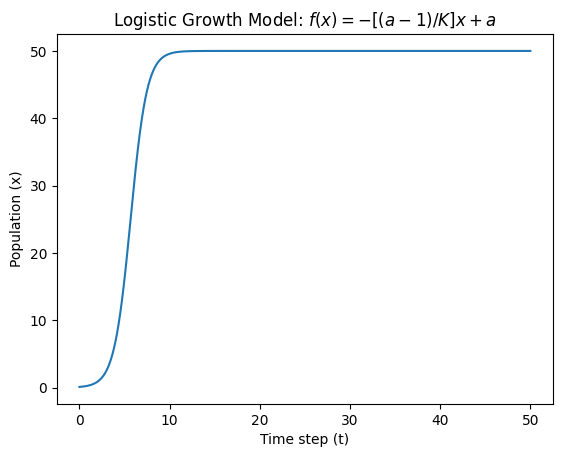

In [29]:
initialize()
while t < 50.:
    update()
    observe()

plot(timesteps, result)
xlabel('Time step (t)')
ylabel('Population (x)')
title(r'Logistic Growth Model: $f(x) = -[{(a-1)}/{K}]x + a$')
show()


##### Optimal Population Model
We first start with the model parameters where
- `K` : the optimal population size
- `a` : the peak growth ratio
- `c` : Smaller curvature keeps f(x) > 1 near x = 10

In [30]:
from pylab import *

# Model Parameters
K = 50.0
a = 1.1
c = 0.00005

**Initialize**

In [31]:
def initialize():
    global x, result
    x = 10.0  # Initial population
    result = [x]

**Observe**

In [32]:
def observe():
    global x, result
    result.append(x)

**Update**

In [33]:
def update():
    global x, result
    # Parabolic growth ratio centered at K
    fx = -c * (x - K)**2 + a
    x = fx * x

Plotting the graph:

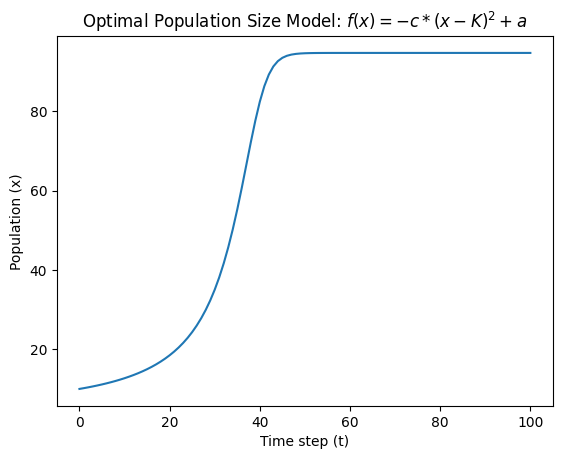

In [34]:
initialize()
for t in range(100):
    update()
    observe()

plot(result)
xlabel('Time step (t)')
ylabel('Population (x)')
title(r'Optimal Population Size Model: $f(x) = -c * (x - K)^2 + a$')
show()

### Comparin Both Models
$$g_\text{log} = \frac{1}{P}\frac{dP}{dt} = r\left(1-\frac
{P}{K}\right), \qquad g_\text{opt} = r\left[1 - \left(\frac{P-K}{K}\right)\right]$$

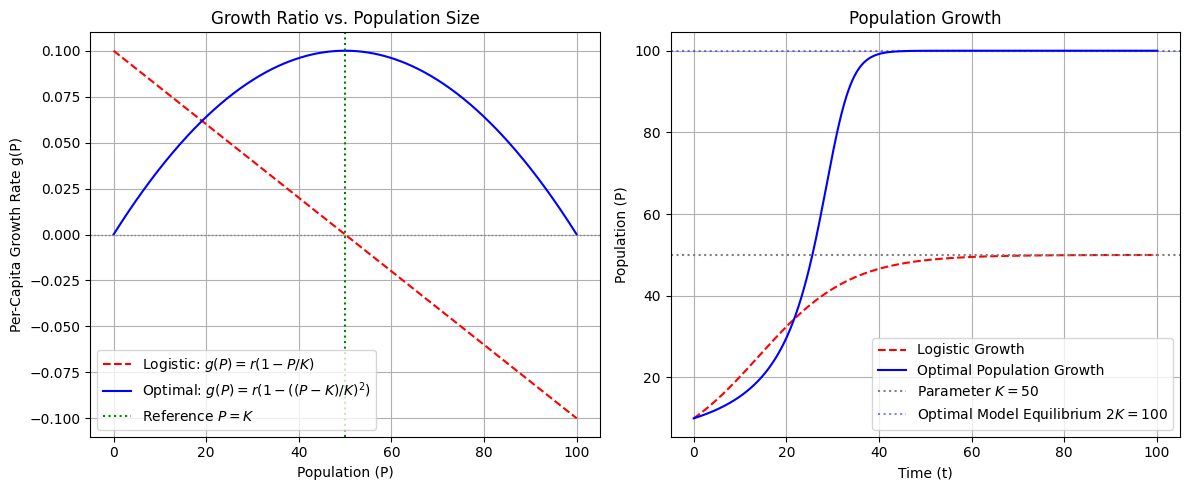

In [35]:
from pylab import *

# Model Parameters
K = 50.0  # Carrying capacity (Logistic) / Optimal population size (Optimal)
r = 0.1   # Growth rate
dt = 0.1  # Time step for numerical integration
t_max = 1000

P_vals = linspace(0, 2*K, 500)
g_log = r * (1 - P_vals / K)
g_opt = r * (1 - ((P_vals - K) / K)**2)

figure(figsize=(12, 5))

# Per-Capita Growth Rate Comparison
subplot(1, 2, 1)
plot(P_vals, g_log, 'r--', label=r'Logistic: $g(P) = r(1 - P/K)$')
plot(P_vals, g_opt, 'b-', label=r'Optimal: $g(P) = r(1 - ((P-K)/K)^2)$')
axhline(0, color='gray', linestyle=':', linewidth=1)
axvline(K, color='green', linestyle=':', label=r'Reference $P = K$')
xlabel('Population (P)')
ylabel('Per-Capita Growth Rate g(P)')
title('Growth Ratio vs. Population Size')
legend()
grid(True)

P0 = 10.0  # Initial population

# Logistic Model
P_log = P0
res_log = [P_log]
for _ in range(t_max):
    dP_dt = r * P_log * (1 - P_log / K)
    P_log += dP_dt * dt
    res_log.append(P_log)

# Optimal Model Simulation
P_opt = P0
res_opt = [P_opt]
for _ in range(t_max):
    dP_dt = r * P_opt * (1 - ((P_opt - K) / K)**2)
    P_opt += dP_dt * dt
    res_opt.append(P_opt)

t_axis = linspace(0, t_max * dt, t_max + 1)

subplot(1, 2, 2)
plot(t_axis, res_log, 'r--', label='Logistic Growth')
plot(t_axis, res_opt, 'b-', label='Optimal Population Growth')
axhline(K, color='gray', linestyle=':', label=r'Parameter $K = 50$')
axhline(2*K, color='blue', linestyle=':', alpha=0.5, label=r'Optimal Model Equilibrium $2K = 100$')
xlabel('Time (t)')
ylabel('Population (P)')
title('Population Growth')
legend()
grid(True)

tight_layout()
show()